# 1. Importing Libraries

In [17]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

# 2. Load Dataset

In [2]:
file_path = "/kaggle/input/datasets/pythonafroz/wind-turbine-scada-data/Aventa_AV7_IET_OST_SCADA.csv"
df = pd.read_csv(file_path, low_memory=False)

# 3. Basic Inspection

In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39715978 entries, 0 to 39715977
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Datetime              object 
 1   RotorSpeed            float64
 2   GeneratorSpeed        float64
 3   GeneratorTemperature  float64
 4   WindSpeed             float64
 5   PowerOutput           float64
 6   SpeiseSpannung        float64
 7   StatusAnlage          float64
 8   MaxWindHeute          float64
 9   offsetWindDirection   float64
 10  PitchDeg              float64
dtypes: float64(10), object(1)
memory usage: 3.3+ GB


# 4. Convert Datetime

In [4]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

# 5. Sort Data

In [5]:
df = df.sort_values("Datetime")

# 6. Set Datetime Index

In [6]:
df.set_index("Datetime", inplace=True)

# 7. Drop Unnecessary CSV columns

In [7]:
df = df[[
    "WindSpeed",
    "RotorSpeed",
    "GeneratorSpeed",
    "GeneratorTemperature",
    "PowerOutput",
    "PitchDeg",
    "StatusAnlage"
]]

# 8. Handle Missing Values

In [8]:
df = df.dropna()

# 9. Downsample

In [9]:
df_resampled = df.resample("1min").mean()

# 10. Reset index

In [10]:
df_resampled = df_resampled.reset_index()

In [11]:
df_resampled.head()
df_resampled.shape


,Datetime,WindSpeed,RotorSpeed,GeneratorSpeed,GeneratorTemperature,PowerOutput,PitchDeg,StatusAnlage
0,2021-12-31 23:00:00,0.00,0.000000,0.0,11.581667,0.0,80.313994,13.0
1,2021-12-31 23:01:00,0.00,0.000000,0.0,11.600000,0.0,80.313994,13.0
2,2021-12-31 23:02:00,0.15,0.000000,0.0,11.575000,0.0,80.313994,13.0
3,2021-12-31 23:03:00,0.00,0.000000,0.0,11.578333,0.0,80.313994,13.0
4,2021-12-31 23:04:00,0.00,0.591667,0.0,11.553333,0.0,80.313994,13.0


# 11. Save Cleaned Dataset

In [13]:
df_resampled.to_csv("/kaggle/working/polaris_cleaned.csv", index=False)

# 12. Rename Columns 

In [14]:
df_resampled.columns = [
    "datetime",
    "wind_speed",
    "rotor_speed",
    "generator_speed",
    "generator_temp",
    "power_output",
    "pitch_angle",
    "turbine_status"
]

# 13. Add Turbine ID

In [15]:
df_resampled["turbine_id"] = "AV7_01"

# 14. Save Final Version

In [16]:
df_resampled.to_csv("/kaggle/working/polaris_cleaned.csv", index=False)

# 15. Load Cleaned Dataset

In [18]:
df = pd.read_csv("/kaggle/working/polaris_cleaned.csv")

# 16. Create SQlite Database

In [19]:
engine = create_engine("sqlite:///polaris.db")

# 17. Push Data into SQL

In [20]:
df.to_sql("turbine_readings", engine, if_exists="replace", index=False)

814980

# 18. Verify Table Exists

In [21]:
pd.read_sql("SELECT * FROM turbine_readings LIMIT 5", engine)

,datetime,wind_speed,rotor_speed,generator_speed,generator_temp,power_output,pitch_angle,turbine_status,turbine_id
0,2021-12-31 23:00:00,0.00,0.000000,0.0,11.581667,0.0,80.313994,13.0,AV7_01
1,2021-12-31 23:01:00,0.00,0.000000,0.0,11.600000,0.0,80.313994,13.0,AV7_01
2,2021-12-31 23:02:00,0.15,0.000000,0.0,11.575000,0.0,80.313994,13.0,AV7_01
3,2021-12-31 23:03:00,0.00,0.000000,0.0,11.578333,0.0,80.313994,13.0,AV7_01
4,2021-12-31 23:04:00,0.00,0.591667,0.0,11.553333,0.0,80.313994,13.0,AV7_01


## Qeury 1 - Daily Power Generation

In [29]:
query = """
SELECT 
DATE(datetime) as date,
ROUND(SUM(power_output), 2) as total_power
FROM turbine_readings
WHERE power_output > 0
GROUP BY date
HAVING total_power > 0
ORDER BY total_power DESC;
"""

daily_power = pd.read_sql(query, engine)
daily_power.head()

,date,total_power
0,2023-02-27,9839.38
1,2023-02-26,9267.97
2,2022-12-23,9054.06
3,2023-01-09,8606.98
4,2022-09-27,7993.85


## Query 2 - Average Operating Conditons

In [23]:
query = """
SELECT 
AVG(wind_speed) as avg_wind,
AVG(generator_temp) as avg_temp,
AVG(power_output) as avg_power
FROM turbine_readings;
"""

pd.read_sql(query, engine)

,avg_wind,avg_temp,avg_power
0,2.529262,28.974247,1.158847


## Query 3 - Temperature Spike Detection

In [24]:
query = """
SELECT datetime, generator_temp
FROM turbine_readings
WHERE generator_temp > 70
ORDER BY generator_temp DESC;
"""

temp_spikes = pd.read_sql(query, engine)
temp_spikes.head()

,datetime,generator_temp
0,2022-02-18 10:25:00,83.071667
1,2023-06-11 18:19:00,82.633333
2,2023-06-11 18:16:00,82.618333
3,2023-06-11 18:18:00,82.615000
4,2023-06-11 18:21:00,82.610169


## Query 4 - Idle vs Active Time

In [25]:
query = """
SELECT 
CASE 
    WHEN power_output = 0 THEN 'Idle'
    ELSE 'Active'
END as state,
COUNT(*) as count
FROM turbine_readings
GROUP BY state;
"""

pd.read_sql(query, engine)

,state,count
0,Active,470793
1,Idle,344187


## Query 5 - Power To Wind Ratio

In [30]:
query = """
SELECT 
datetime,
ROUND(power_output / wind_speed, 3) as efficiency
FROM turbine_readings
WHERE wind_speed > 0 
AND power_output > 0
AND wind_speed IS NOT NULL
ORDER BY efficiency DESC
LIMIT 1000;
"""

pd.read_sql(query, engine)

,datetime,efficiency
0,2022-10-18 10:04:00,5.973
1,2022-01-20 16:40:00,2.250
2,2022-12-15 18:23:00,2.201
3,2022-01-19 14:23:00,1.565
4,2022-01-19 17:53:00,1.562
...,...,...
995,2022-03-19 07:24:00,1.385
996,2022-04-21 17:05:00,1.385
997,2022-04-25 16:46:00,1.385
998,2022-12-03 13:23:00,1.385


## Query 6 - Hourly Power Trend

In [27]:
query = """
SELECT 
strftime('%H', datetime) as hour,
AVG(power_output) as avg_power
FROM turbine_readings
GROUP BY hour
ORDER BY hour;
"""

pd.read_sql(query, engine)

,hour,avg_power
0,00,0.823014
1,01,0.835413
2,02,0.792476
3,03,0.749972
4,04,0.770095
5,05,0.742198
6,06,0.870106
7,07,1.070378
8,08,1.212414
9,09,1.407536


# 19. EDA using Python

## 19.1 Loading Data From SQL and basic Setup

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sql("SELECT * FROM turbine_readings", engine)
df["datetime"] = pd.to_datetime(df["datetime"])

## 19.2 Power Curve

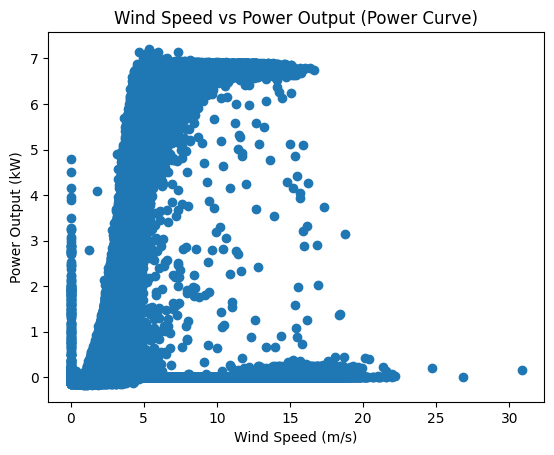

In [33]:
plt.figure()
plt.scatter(df["wind_speed"], df["power_output"])
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power Output (kW)")
plt.title("Wind Speed vs Power Output (Power Curve)")
plt.show()

## 19.3 Windspeed distribution

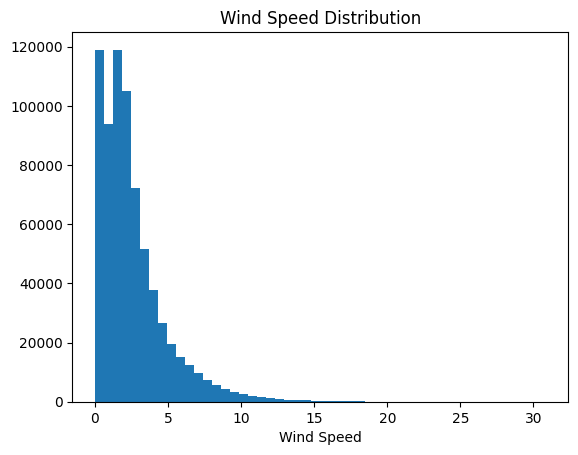

In [34]:
plt.figure()
plt.hist(df["wind_speed"], bins=50)
plt.xlabel("Wind Speed")
plt.title("Wind Speed Distribution")
plt.show()

## 19.4 Temperature Over Time

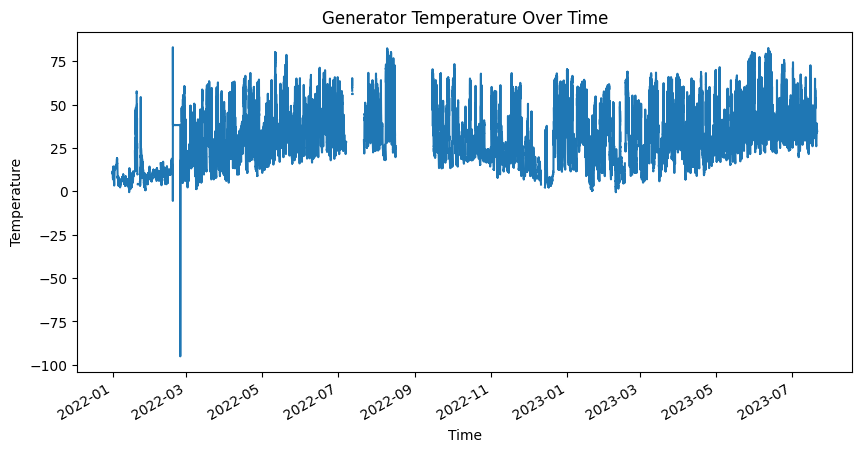

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(df["datetime"], df["generator_temp"])
plt.gcf().autofmt_xdate() 
plt.title("Generator Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

## 19.5 Power Output Over Time

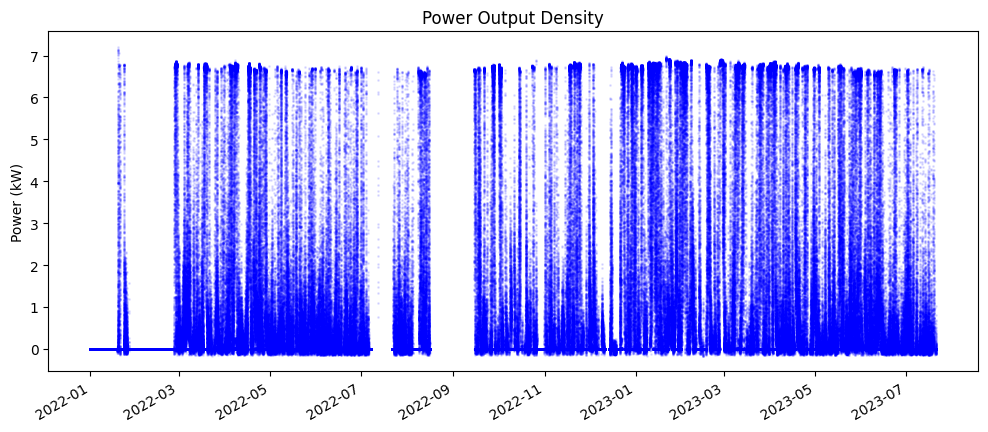

In [44]:
plt.figure(figsize=(12, 5))
plt.scatter(df["datetime"], df["power_output"], alpha=0.1, s=1, color='blue')
plt.title("Power Output Density")
plt.ylabel("Power (kW)")
plt.gcf().autofmt_xdate()
plt.show()

## 19.6 Correlation Heatmap

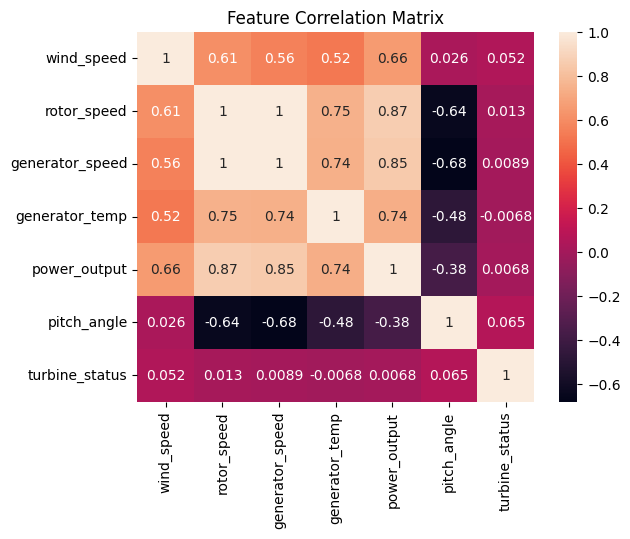

In [47]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

## 19.7 Power to Wind ratio Distribution

/tmp/ipykernel_55/2173769128.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eff["efficiency"] = df_eff["power_output"] / df_eff["wind_speed"]


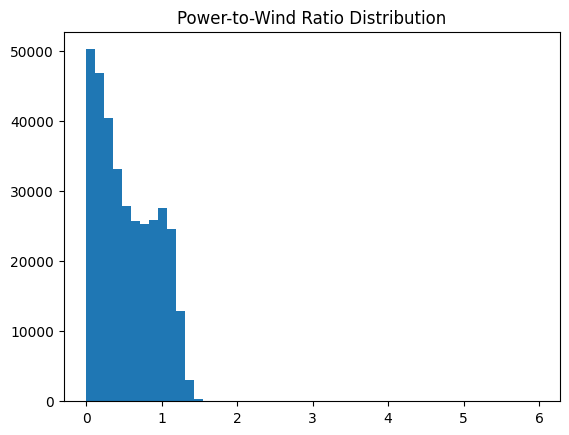

In [40]:
df_eff = df[(df["wind_speed"] > 0) & (df["power_output"] > 0)]
df_eff["efficiency"] = df_eff["power_output"] / df_eff["wind_speed"]
plt.figure()
plt.hist(df_eff["efficiency"], bins=50)
plt.title("Power-to-Wind Ratio Distribution")
plt.show()